In [1]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os

# Add project root (210226) to Python path
sys.path.append(os.path.abspath(".."))

from utils.prepare_data import prepare_data

In [3]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [ ]:
# from qiskit_ibm_runtime import QiskitRuntimeService
 
# QiskitRuntimeService.save_account(
#   token=token,
#   overwrite=True
# )

In [5]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [6]:
dataset_path = '../dataset/Dataset_TehHijau.csv'
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    'full', 
    'linear', 
    'circular', 
    'pauli_x', 
    'pauli_y', 
    'pauli_z'
]
kernel_types = [
    'linear', 
    'poly', 
    'rbf', 
    'sigmoid'
]

In [7]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,...,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
4,90.0,42.0,48.0,132.0,95.0,46.0,552.0,289.0,546.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
5,90.0,42.0,46.0,132.0,96.0,45.0,552.0,289.0,545.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
6,89.0,43.0,46.0,133.0,96.0,45.0,552.0,291.0,546.0,369.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
7,90.0,42.0,46.0,132.0,96.0,46.0,551.0,290.0,547.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
8,90.0,41.0,47.0,132.0,97.0,46.0,550.0,290.0,548.0,370.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
9,90.0,41.0,48.0,132.0,95.0,46.0,551.0,289.0,547.0,371.0,...,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8


Text(0.5, 1.0, 'Histogram for the Kategori')

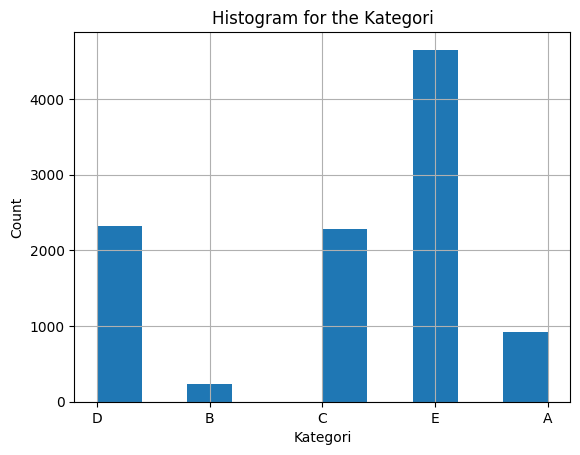

In [8]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [9]:
from utils.prepare_data import prepare_data
from model.evaluate import evaluate_svc, evaluate_xgboost, evaluate_catboost, evaluate_quantum, evaluate_libsvm

random_state = [10, 42, 100, 2021, 1234]
all_results = []

for state in random_state:
    print(f"Evaluating models with random state {state}")
    data = prepare_data(
        # dataset_path=dataset_path, 
        feature_cols=feature_cols,
        target_cols=target_cols,
        # random_state=state,
        manual=True,
        manualDirPath =f"../dataset/manual/{state}",
    )

    model_outputs = {
        "SVC": evaluate_svc(data, kernel_types),
        "XGBoost": evaluate_xgboost(data, kernel_types),
        "CatBoost": evaluate_catboost(data, kernel_types),
        "Quantum": evaluate_quantum(data, quantum_kernel_types),
        "LibSVM": evaluate_libsvm(data, kernel_types)
    }

    for model_name, results in model_outputs.items():
        for r in results:
            r_copy = r.copy()
            r_copy["model"] = model_name
            r_copy["random_state"] = state
            all_results.append(r_copy)

Evaluating models with random state 10
Evaluating models with random state 42
Evaluating models with random state 100
Evaluating models with random state 2021
Evaluating models with random state 1234


In [10]:
import pandas as pd

df = pd.DataFrame(all_results)

summary = (
    df
    .groupby(["model", "kernel"])
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        mean_f1=("f1-score", "mean"),
        std_f1=("f1-score", "std"),
        mean_val_acc=("val_accuracy", "mean"),
        std_val_acc=("val_accuracy", "std"),
        mean_total_time=("total_time", "mean")
    )
    .reset_index()
)

N_train = 7286
N_val   = 1561
N_test  = 1562


=== KOMPOSISI KELAS DATASET (Sample dari Run Terakhir) ===
   Train  Validation  Test
0    649         146   132
1    164          34    31
2   1595         339   353
3   1616         349   352
4   3262         693   694

                                                                 PERFORMANCE SUMMARY                                                                  
Model                | Val Acc    | Acc        | Prec       | Recall     | F1         | Total(s)  
------------------------------------------------------------------------------------------------------------------------------------------------------
SVC - Linear         | 0.537±0.010 | 0.531±0.006 | 0.470±0.013 | 0.531±0.006 | 0.437±0.008 | 3.64±0.22
SVC - Poly           | 0.775±0.007 | 0.777±0.010 | 0.804±0.008 | 0.777±0.010 | 0.770±0.010 | 1.66±0.05
SVC - Rbf            | 0.947±0.005 | 0.943±0.005 | 0.944±0.005 | 0.943±0.005 | 0.943±0.005 | 1.77±0.09
SVC - Sigmoid        

<Figure size 640x480 with 0 Axes>

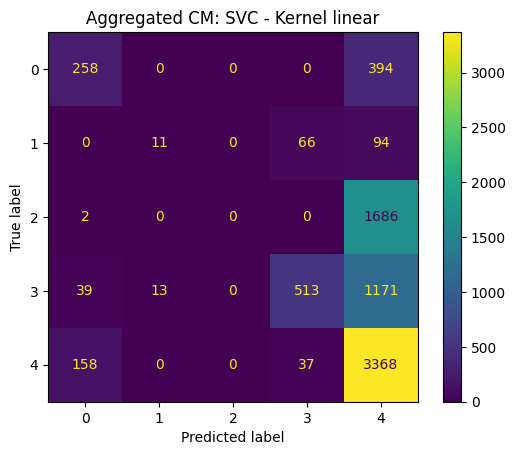

<Figure size 640x480 with 0 Axes>

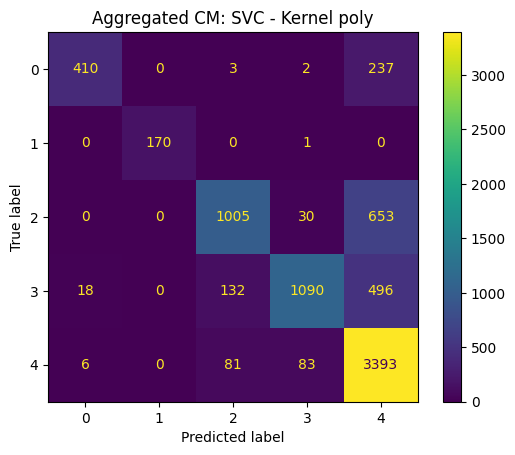

<Figure size 640x480 with 0 Axes>

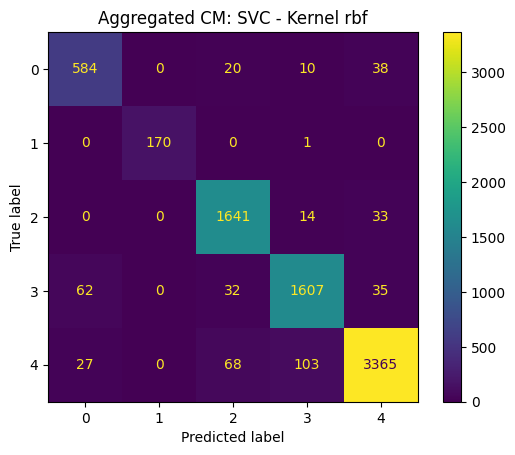

<Figure size 640x480 with 0 Axes>

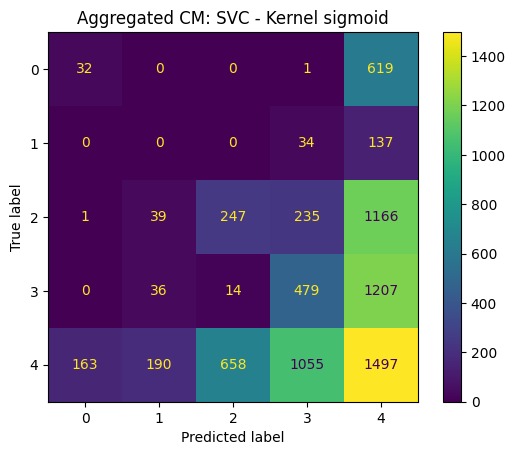

<Figure size 640x480 with 0 Axes>

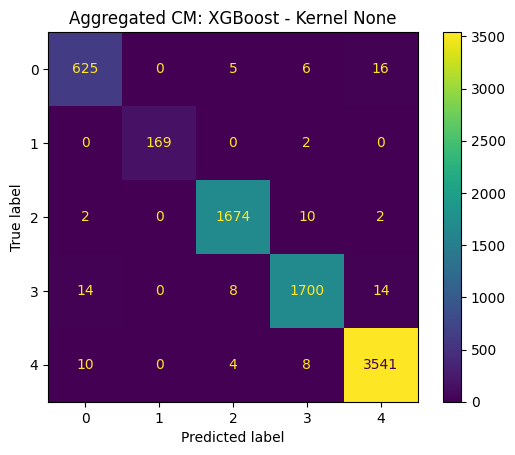

<Figure size 640x480 with 0 Axes>

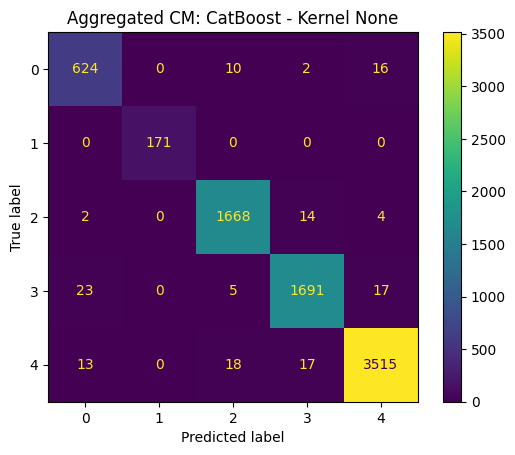

<Figure size 640x480 with 0 Axes>

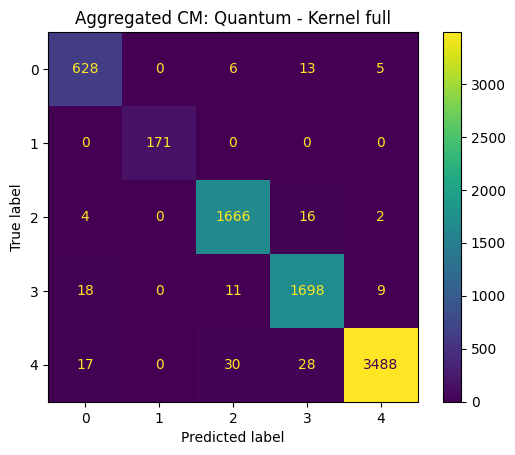

<Figure size 640x480 with 0 Axes>

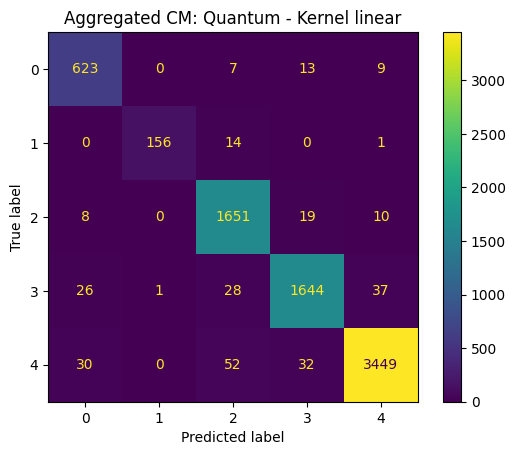

<Figure size 640x480 with 0 Axes>

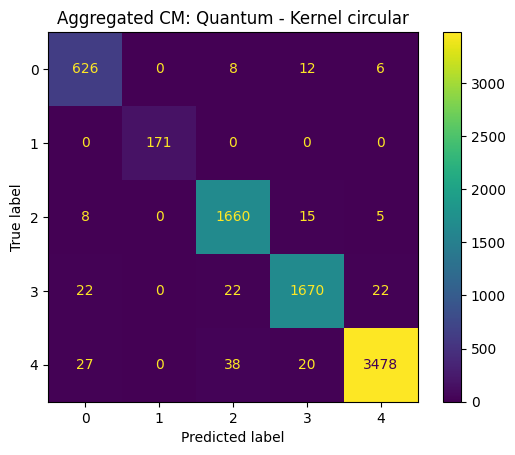

<Figure size 640x480 with 0 Axes>

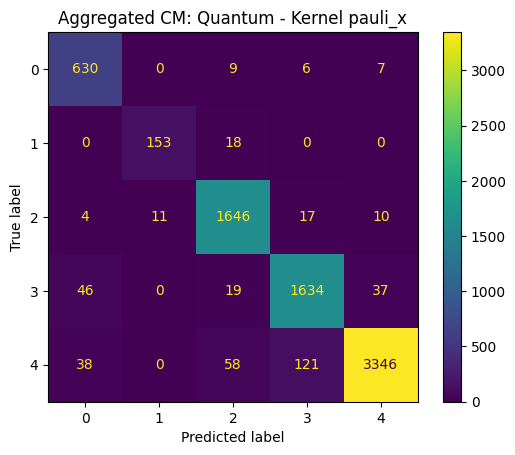

<Figure size 640x480 with 0 Axes>

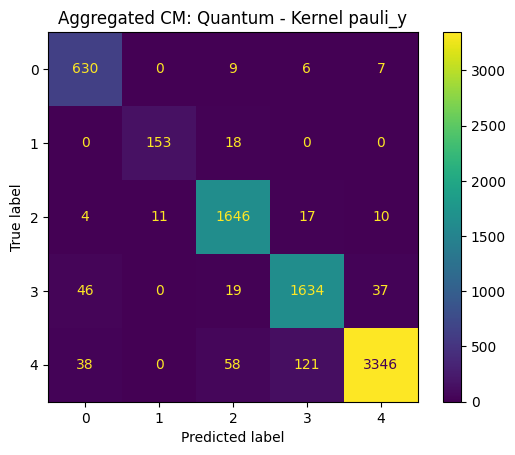

<Figure size 640x480 with 0 Axes>

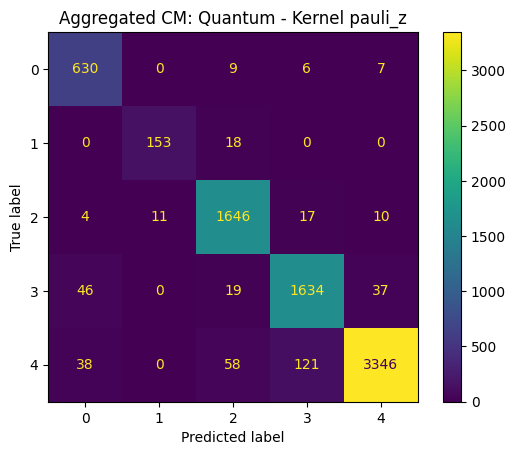

<Figure size 640x480 with 0 Axes>

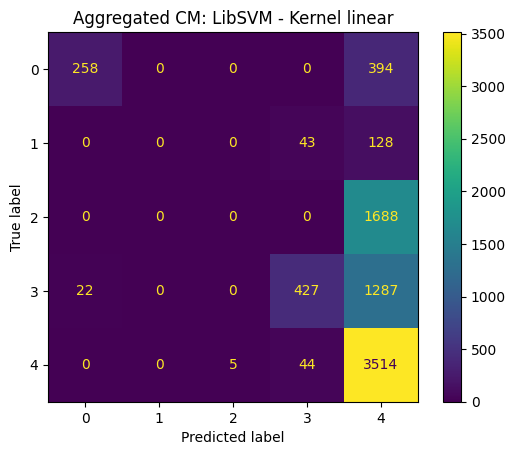

<Figure size 640x480 with 0 Axes>

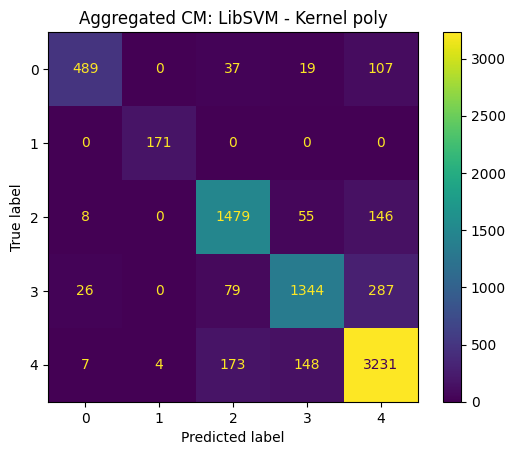

<Figure size 640x480 with 0 Axes>

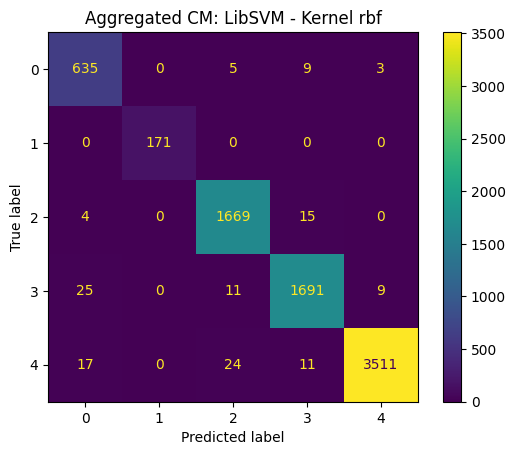

<Figure size 640x480 with 0 Axes>

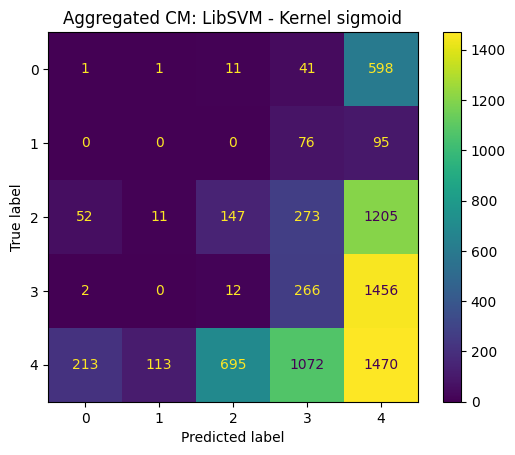

In [11]:
from utils.aggregate_result import aggregate_results
from utils.report import report
from utils.conf_matrix import plot_conf_matrix

# 1. Agregasi hasil
final_aggregated_results = aggregate_results(all_results)

# 2. Print tabel metrik
# (Pastikan fungsi report Anda di-update juga jika ingin print kolom 'model')
report(final_aggregated_results, data, is_aggregated=True)

# 3. Plot Grand Confusion Matrix
for result in final_aggregated_results:
    title = f"Aggregated CM: {result['model']} - Kernel {result['kernel']}"
    plot_conf_matrix(result['confusion_matrix_sum'], title=title)